In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter
from sklearn.preprocessing import LabelEncoder

/Users/David/opt/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [ ]:
df = pd.read_csv('data/telco.csv')
df.drop(columns=['ID'], inplace=True)
df.dropna(inplace=True)

In [ ]:
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [ ]:
df['event'] = df['churn'].astype(int)
df['T'] = df['tenure']
df['E'] = df['event']
df.drop(columns=['churn', 'tenure', 'event'], inplace=True)

In [ ]:
aft_data = df.copy()
models = {
    'Weibull': WeibullAFTFitter(),
    'LogNormal': LogNormalAFTFitter(),
    'LogLogistic': LogLogisticAFTFitter()
}

fitted_models = {}
for name, model in models.items():
    model.fit(aft_data, duration_col='T', event_col='E')
    fitted_models[name] = model

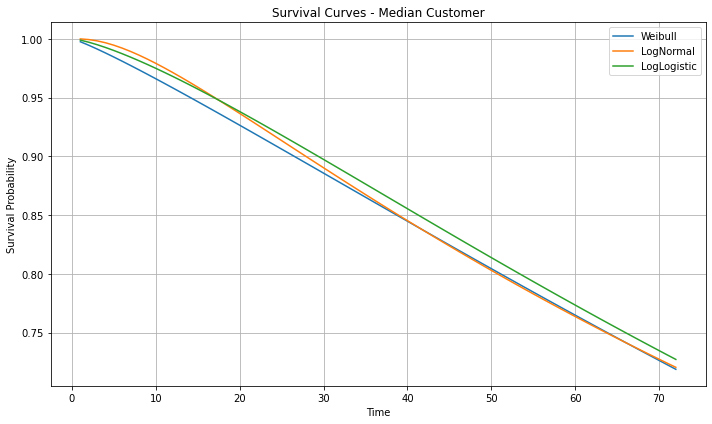

In [ ]:
sample = aft_data.drop(columns=['T', 'E']).median().to_frame().T

plt.figure(figsize=(10, 6))
for name, model in fitted_models.items():
    surv_func = model.predict_survival_function(sample)
    plt.plot(surv_func.index, surv_func.values.flatten(), label=name)

plt.title("Survival Curves - Median Customer")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
for name, model in fitted_models.items():
    print(f"=== {name} AFT Model Summary ===")
    model.print_summary()

=== Weibull AFT Model Summary ===


<lifelines.WeibullAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'T'
                event col = 'E'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1475.19
         time fit was run = 2025-05-01 18:26:41 UTC

---
                    coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
param   covariate                                                                                                         
lambda_ address     0.04       1.04       0.01             0.03             0.06                 1.03                 1.06
        age         0.03       1.03       0.01             0.02             0.04                 1.02                 1.04
        custcat     0.34       1.41       0.07             0.20             0.48                 1.22                 1.62
        ed          0.06       1.06       0.04            -0.01             0.13                 0.99                 1.14
        forward    -0.33       0.72       0.14            -0.61            -0.05                 0.55                 0.95
        gender     -0.03       0.97       0.11            -0.24             0.18                 0.79                 1.20
        income      0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
        internet   -0.77       0.46       0.12            -1.01            -0.53                 0.37                 0.59
        marital    -0.41       0.67       0.11            -0.62            -0.20                 0.54                 0.82
        region      0.06       1.07       0.06            -0.06             0.19                 0.94                 1.21
        retire      0.22       1.25       0.54            -0.84             1.28                 0.43                 3.61
        voice      -0.45       0.64       0.14            -0.73            -0.18                 0.48                 0.84
        Intercept   3.19      24.32       0.27             2.67             3.71                14.42                41.03
rho_    Intercept   0.13       1.14       0.05             0.03             0.23                 1.03                 1.26

                    cmp to     z      p   -log2(p)
param   covariate                                 
lambda_ address       0.00  4.78 <0.005      19.11
        age           0.00  4.17 <0.005      14.99
        custcat       0.00  4.66 <0.005      18.26
        ed            0.00  1.67   0.10       3.39
        forward       0.00 -2.29   0.02       5.50
        gender        0.00 -0.30   0.77       0.38
        income        0.00  0.91   0.36       1.46
        internet      0.00 -6.36 <0.005      32.18
        marital       0.00 -3.78 <0.005      12.62
        region        0.00  0.99   0.32       1.63
        retire        0.00  0.40   0.69       0.54
        voice         0.00 -3.25 <0.005       9.74
        Intercept     0.00 11.96 <0.005     107.15
rho_    Intercept     0.00  2.61   0.01       6.81
---
Concordance = 0.78
AIC = 2978.39
log-likelihood ratio test = 262.47 on 12 df
-log2(p) of ll-ratio test = 161.00

=== LogNormal AFT Model Summary ===


<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'T'
                event col = 'E'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1467.82
         time fit was run = 2025-05-01 18:26:41 UTC

---
                   coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
param  covariate                                                                                                         
mu_    address     0.04       1.05       0.01             0.03             0.06                 1.03                 1.06
       age         0.04       1.04       0.01             0.02             0.05                 1.02                 1.05
       custcat     0.44       1.56       0.08             0.28             0.61                 1.32                 1.84
       ed          0.06       1.06       0.04            -0.02             0.14                 0.98                 1.15
       forward    -0.39       0.68       0.17            -0.72            -0.06                 0.49                 0.95
       gender      0.03       1.03       0.12            -0.20             0.26                 0.81                 1.29
       income      0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
       internet   -0.80       0.45       0.13            -1.06            -0.55                 0.35                 0.58
       marital    -0.49       0.61       0.12            -0.72            -0.26                 0.49                 0.77
       region      0.03       1.03       0.07            -0.11             0.17                 0.90                 1.19
       retire     -0.03       0.97       0.45            -0.92             0.86                 0.40                 2.36
       voice      -0.64       0.53       0.16            -0.95            -0.32                 0.39                 0.73
       Intercept   2.66      14.34       0.28             2.11             3.22                 8.22                25.03
sigma_ Intercept   0.31       1.36       0.05             0.22             0.40                 1.24                 1.49

                   cmp to     z      p   -log2(p)
param  covariate                                 
mu_    address       0.00  4.90 <0.005      19.96
       age           0.00  4.80 <0.005      19.24
       custcat       0.00  5.32 <0.005      23.20
       ed            0.00  1.47   0.14       2.82
       forward       0.00 -2.29   0.02       5.50
       gender        0.00  0.22   0.83       0.27
       income        0.00  1.23   0.22       2.19
       internet      0.00 -6.15 <0.005      30.25
       marital       0.00 -4.13 <0.005      14.78
       region        0.00  0.45   0.65       0.62
       retire        0.00 -0.07   0.95       0.08
       voice         0.00 -3.93 <0.005      13.54
       Intercept     0.00  9.37 <0.005      66.96
sigma_ Intercept     0.00  6.69 <0.005      35.37
---
Concordance = 0.78
AIC = 2963.64
log-likelihood ratio test = 269.39 on 12 df
-log2(p) of ll-ratio test = 165.81

=== LogLogistic AFT Model Summary ===


<lifelines.LogLogisticAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'T'
                event col = 'E'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1469.43
         time fit was run = 2025-05-01 18:26:41 UTC

---
                   coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
param  covariate                                                                                                         
alpha_ address     0.04       1.04       0.01             0.02             0.06                 1.02                 1.06
       age         0.03       1.03       0.01             0.02             0.05                 1.02                 1.05
       custcat     0.43       1.53       0.08             0.27             0.59                 1.31                 1.80
       ed          0.05       1.05       0.04            -0.02             0.12                 0.98                 1.13
       forward    -0.38       0.68       0.16            -0.70            -0.07                 0.50                 0.94
       gender      0.01       1.01       0.11            -0.21             0.23                 0.81                 1.26
       income      0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
       internet   -0.82       0.44       0.13            -1.07            -0.58                 0.34                 0.56
       marital    -0.49       0.61       0.11            -0.71            -0.27                 0.49                 0.77
       region      0.06       1.06       0.07            -0.07             0.20                 0.93                 1.22
       retire      0.10       1.10       0.50            -0.88             1.08                 0.41                 2.93
       voice      -0.59       0.55       0.16            -0.89            -0.29                 0.41                 0.75
       Intercept   2.71      15.08       0.27             2.18             3.25                 8.85                25.69
beta_  Intercept   0.30       1.36       0.05             0.20             0.40                 1.23                 1.50

                   cmp to     z      p   -log2(p)
param  covariate                                 
alpha_ address       0.00  4.65 <0.005      18.21
       age           0.00  4.74 <0.005      18.83
       custcat       0.00  5.27 <0.005      22.81
       ed            0.00  1.32   0.19       2.42
       forward       0.00 -2.36   0.02       5.79
       gender        0.00  0.09   0.93       0.10
       income        0.00  0.97   0.33       1.59
       internet      0.00 -6.57 <0.005      34.26
       marital       0.00 -4.29 <0.005      15.76
       region        0.00  0.88   0.38       1.39
       retire        0.00  0.20   0.84       0.24
       voice         0.00 -3.80 <0.005      12.77
       Intercept     0.00  9.98 <0.005      75.48
beta_  Intercept     0.00  5.98 <0.005      28.71
---
Concordance = 0.78
AIC = 2966.85
log-likelihood ratio test = 271.56 on 12 df
-log2(p) of ll-ratio test = 167.32

In [10]:
final_model = fitted_models["LogNormal"]
final_model.print_summary()

<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'T'
                event col = 'E'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1467.82
         time fit was run = 2025-05-01 18:26:41 UTC

---
                   coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
param  covariate                                                                                                         
mu_    address     0.04       1.05       0.01             0.03             0.06                 1.03                 1.06
       age         0.04       1.04       0.01             0.02             0.05                 1.02                 1.05
       custcat     0.44       1.56       0.08             0.28             0.61                 1.32                 1.84
       ed          0.06       1.06       0.04            -0.02             0.14                 0.98                 1.15
       forward    -0.39       0.68       0.17            -0.72            -0.06                 0.49                 0.95
       gender      0.03       1.03       0.12            -0.20             0.26                 0.81                 1.29
       income      0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
       internet   -0.80       0.45       0.13            -1.06            -0.55                 0.35                 0.58
       marital    -0.49       0.61       0.12            -0.72            -0.26                 0.49                 0.77
       region      0.03       1.03       0.07            -0.11             0.17                 0.90                 1.19
       retire     -0.03       0.97       0.45            -0.92             0.86                 0.40                 2.36
       voice      -0.64       0.53       0.16            -0.95            -0.32                 0.39                 0.73
       Intercept   2.66      14.34       0.28             2.11             3.22                 8.22                25.03
sigma_ Intercept   0.31       1.36       0.05             0.22             0.40                 1.24                 1.49

                   cmp to     z      p   -log2(p)
param  covariate                                 
mu_    address       0.00  4.90 <0.005      19.96
       age           0.00  4.80 <0.005      19.24
       custcat       0.00  5.32 <0.005      23.20
       ed            0.00  1.47   0.14       2.82
       forward       0.00 -2.29   0.02       5.50
       gender        0.00  0.22   0.83       0.27
       income        0.00  1.23   0.22       2.19
       internet      0.00 -6.15 <0.005      30.25
       marital       0.00 -4.13 <0.005      14.78
       region        0.00  0.45   0.65       0.62
       retire        0.00 -0.07   0.95       0.08
       voice         0.00 -3.93 <0.005      13.54
       Intercept     0.00  9.37 <0.005      66.96
sigma_ Intercept     0.00  6.69 <0.005      35.37
---
Concordance = 0.78
AIC = 2963.64
log-likelihood ratio test = 269.39 on 12 df
-log2(p) of ll-ratio test = 165.81

In [ ]:
final_model = fitted_models["LogNormal"] 

summary = final_model.summary.copy()
summary = summary.reset_index()

summary.columns = ['param', 'variable'] + list(summary.columns[2:])
summary['full_name'] = summary['param'] + "_" + summary['variable']

mask = (summary['p'] < 0.05) & (~summary['variable'].str.lower().str.contains("intercept"))
significant_vars = summary.loc[mask, 'variable'].unique()

print("Significant features:", list(significant_vars))

Significant features: ['address', 'age', 'custcat', 'forward', 'internet', 'marital', 'voice']


In [ ]:
aft_data_reduced = aft_data[['address', 'age', 'custcat', 'forward', 'internet', 'marital', 'voice', 'T', 'E']]

from lifelines import LogNormalAFTFitter

final_model_reduced = LogNormalAFTFitter()
final_model_reduced.fit(aft_data_reduced, duration_col="T", event_col="E")
final_model_reduced.print_summary()

<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'T'
                event col = 'E'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1469.97
         time fit was run = 2025-05-01 18:27:23 UTC

---
                   coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
param  covariate                                                                                                         
mu_    address     0.05       1.05       0.01             0.03             0.06                 1.03                 1.07
       age         0.04       1.04       0.01             0.02             0.05                 1.03                 1.05
       custcat     0.44       1.55       0.08             0.28             0.60                 1.32                 1.83
       forward    -0.37       0.69       0.17            -0.70            -0.04                 0.50                 0.96
       internet   -0.80       0.45       0.13            -1.06            -0.55                 0.35                 0.58
       marital    -0.47       0.62       0.12            -0.71            -0.24                 0.49                 0.78
       voice      -0.62       0.54       0.16            -0.94            -0.30                 0.39                 0.74
       Intercept   2.77      15.96       0.25             2.29             3.25                 9.85                25.87
sigma_ Intercept   0.31       1.37       0.05             0.22             0.40                 1.25                 1.50

                   cmp to     z      p   -log2(p)
param  covariate                                 
mu_    address       0.00  4.99 <0.005      20.65
       age           0.00  5.74 <0.005      26.69
       custcat       0.00  5.28 <0.005      22.86
       forward       0.00 -2.19   0.03       5.11
       internet      0.00 -6.15 <0.005      30.29
       marital       0.00 -4.03 <0.005      14.12
       voice         0.00 -3.83 <0.005      12.96
       Intercept     0.00 11.25 <0.005      95.11
sigma_ Intercept     0.00  6.79 <0.005      36.41
---
Concordance = 0.78
AIC = 2957.95
log-likelihood ratio test = 265.09 on 7 df
-log2(p) of ll-ratio test = 175.30

In [ ]:
df_clv = aft_data_reduced.copy()
df_clv['predicted_lifetime'] = final_model_reduced.predict_expectation(df_clv)
df_clv['income'] = aft_data.loc[df_clv.index, 'income']  # re-attach income from original data
df_clv['CLV'] = df_clv['predicted_lifetime'] * df_clv['income'] * 1000  # income is in K

print(df_clv['CLV'].describe())

count    1.000000e+03
mean     4.790051e+07
std      1.225912e+08
min      2.443716e+05
25%      4.433814e+06
50%      1.147054e+07
75%      3.929237e+07
max      1.625262e+09
Name: CLV, dtype: float64


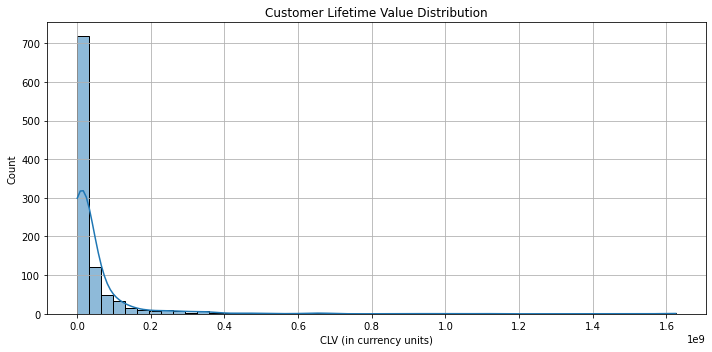

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clv['CLV'], bins=50, kde=True)
plt.title("Customer Lifetime Value Distribution")
plt.xlabel("CLV (in currency units)")
plt.ylabel("Count")
plt.tight_layout()
plt.grid(True)
plt.show()

In [ ]:
df_clv['segment'] = df_clv['internet'].astype(str) + "_" + df_clv['voice'].astype(str)

segment_stats = df_clv.groupby('segment')['CLV'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(segment_stats)

                 mean  count
segment                     
0_1      8.412699e+07    116
0_0      5.741825e+07    516
1_1      2.697120e+07    188
1_0      1.912987e+07    180


In [ ]:
one_year_surv = final_model_reduced.predict_survival_function(df_clv, times=[12]).T
df_clv['p_survive_12m'] = one_year_surv[12]

df_clv['at_risk'] = df_clv['p_survive_12m'] < 0.5

at_risk_stats = df_clv[df_clv['at_risk']].agg({'CLV': 'sum', 'at_risk': 'count'})
print(at_risk_stats)

CLV        1.316655e+07
at_risk    1.300000e+01
dtype: float64


In [ ]:
retention_budget = df_clv[df_clv['at_risk']]['CLV'].sum() * 0.05 
print(f"Suggested retention budget: {retention_budget:,.0f}")

Suggested retention budget: 658,328
